# Student Marks Prediction Using Linear Regression

## Mini AI/ML Project

### Project Description
This project predicts a student's marks based on the number of study hours using the Linear Regression algorithm. The model learns the relationship between study hours and marks from historical data and predicts marks for new study hour inputs.

---

### Objectives
- Load and understand the dataset.
- Visualize the relationship between study hours and marks.
- Train a Linear Regression model.
- Evaluate the model's performance.
- Predict student marks based on study hours.

---

### Technologies Used
- Python
- Jupyter Notebook
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

---

### Machine Learning Algorithm
**Linear Regression**

---

### Dataset
The dataset contains two columns:

- **Hours** → Number of study hours
- **Scores** → Student marks obtained

---

### Expected Outcome
The trained model predicts the marks a student is likely to score based on the number of hours studied.

In [1]:
# ==========================================
# IMPORT REQUIRED LIBRARIES
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print("All libraries imported successfully.")

All libraries imported successfully.


In [2]:
# ==========================================
# LOAD DATASET
# ==========================================

df = pd.read_csv(r"C:\Users\home\Downloads\archive\student_data.csv")

print("Dataset Loaded Successfully")

print("\nFirst Five Rows")
display(df.head())

print("\nDataset Shape")
print(df.shape)

print("\nDataset Information")
df.info()

print("\nStatistical Summary")
display(df.describe())

print("\nMissing Values")
print(df.isnull().sum())

Dataset Loaded Successfully

First Five Rows


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10



Dataset Shape
(395, 33)

Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nurs

,age,Medu,Fedu,traveltime,studytime,failures,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000



Missing Values
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64


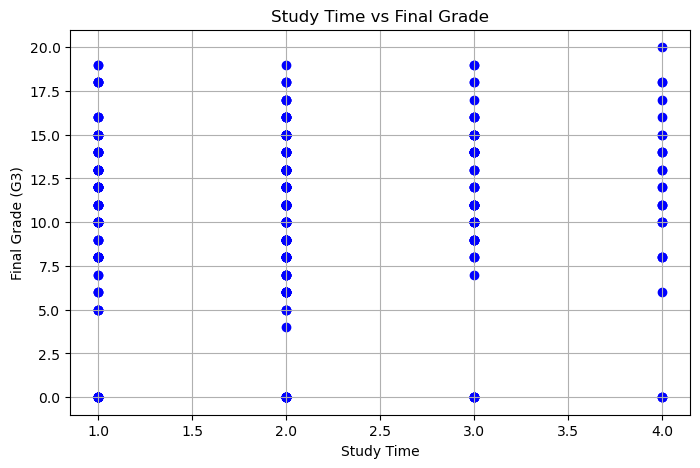

In [7]:
# ==========================================
# DATA VISUALIZATION
# ==========================================

import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.scatter(df["studytime"], df["G3"], color="blue")

plt.title("Study Time vs Final Grade")

plt.xlabel("Study Time")

plt.ylabel("Final Grade (G3)")

plt.grid(True)

plt.show()

In [8]:
# ==========================================
# PREPARE DATA
# ==========================================

X = df[["studytime"]]

y = df["G3"]

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Samples :", len(X_train))
print("Testing Samples :", len(X_test))

Training Samples : 316
Testing Samples : 79


In [9]:
# ==========================================
# TRAIN MODEL
# ==========================================

from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model Trained Successfully")

print("Slope :", model.coef_[0])

print("Intercept :", model.intercept_)

Model Trained Successfully
Slope : 0.7586013704730588
Intercept : 8.772737067417504


In [10]:
# ==========================================
# MODEL EVALUATION
# ==========================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)

print("Model Evaluation")

print("----------------------------")

print("Mean Absolute Error :", round(mean_absolute_error(y_test,y_pred),2))

print("Mean Squared Error :", round(mean_squared_error(y_test,y_pred),2))

print("R² Score :", round(r2_score(y_test,y_pred),3))

results = pd.DataFrame({
    "Actual Grade": y_test.values,
    "Predicted Grade": np.round(y_pred,2)
})

display(results.head(10))

Model Evaluation
----------------------------
Mean Absolute Error : 3.68
Mean Squared Error : 21.49
R² Score : -0.048


,Actual Grade,Predicted Grade
0,10,9.53
1,12,9.53
2,5,10.29
3,10,10.29
4,9,10.29
5,13,10.29
6,18,10.29
7,6,10.29
8,0,10.29
9,14,10.29


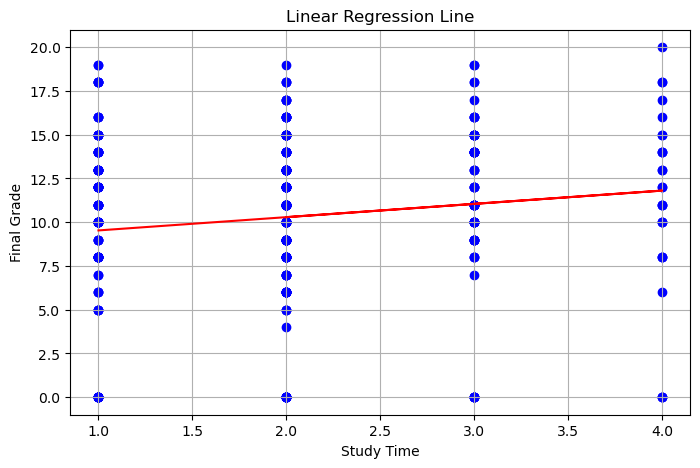

In [11]:
# ==========================================
# REGRESSION LINE
# ==========================================

plt.figure(figsize=(8,5))

plt.scatter(df["studytime"], df["G3"], color="blue")

plt.plot(df["studytime"],
         model.predict(df[["studytime"]]),
         color="red")

plt.title("Linear Regression Line")

plt.xlabel("Study Time")

plt.ylabel("Final Grade")

plt.grid(True)

plt.show()

In [12]:
# ==========================================
# USER PREDICTION
# ==========================================

study_time = float(input("Enter Study Time (1-4 hours category): "))

prediction = model.predict([[study_time]])

print()

print("Predicted Final Grade (G3): {:.2f}".format(prediction[0]))

Enter Study Time (1-4 hours category):  3



Predicted Final Grade (G3): 11.05


C:\Users\home\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:
# ==========================================
# MULTIPLE PREDICTIONS
# ==========================================

study_times = [1, 2, 3, 4]

predictions = model.predict(pd.DataFrame(study_times, columns=["studytime"]))

prediction_df = pd.DataFrame({
    "Study Time": study_times,
    "Predicted Final Grade": np.round(predictions, 2)
})

print("Predicted Grades for Different Study Time Categories")
display(prediction_df)

Predicted Grades for Different Study Time Categories


,Study Time,Predicted Final Grade
0,1,9.53
1,2,10.29
2,3,11.05
3,4,11.81


In [14]:
# ==========================================
# MODEL SUMMARY
# ==========================================

print("="*50)
print("LINEAR REGRESSION MODEL SUMMARY")
print("="*50)

print(f"Feature Used      : Study Time")
print(f"Target Variable   : Final Grade (G3)")
print(f"Training Samples  : {len(X_train)}")
print(f"Testing Samples   : {len(X_test)}")

print(f"\nSlope (Coefficient): {model.coef_[0]:.4f}")
print(f"Intercept          : {model.intercept_:.4f}")

print(f"\nR² Score           : {r2_score(y_test,y_pred):.4f}")

print("\nModel trained successfully.")

LINEAR REGRESSION MODEL SUMMARY
Feature Used      : Study Time
Target Variable   : Final Grade (G3)
Training Samples  : 316
Testing Samples   : 79

Slope (Coefficient): 0.7586
Intercept          : 8.7727

R² Score           : -0.0482

Model trained successfully.


In [7]:
import pandas as pd

# Load dataset
df = pd.read_csv(r"C:\Users\home\Downloads\archive\student_data.csv")

print("Dataset Loaded Successfully")
print(df.head())

Dataset Loaded Successfully
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  ...  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher  ...   
1     GP   F   17       U     GT3       T     1     1  at_home     other  ...   
2     GP   F   15       U     LE3       T     1     1  at_home     other  ...   
3     GP   F   15       U     GT3       T     4     2   health  services  ...   
4     GP   F   16       U     GT3       T     3     3    other     other  ...   

  famrel freetime  goout  Dalc  Walc health absences  G1  G2  G3  
0      4        3      4     1     1      3        6   5   6   6  
1      5        3      3     1     1      3        4   5   5   6  
2      4        3      2     2     3      3       10   7   8  10  
3      3        2      2     1     1      5        2  15  14  15  
4      4        3      2     1     2      5        4   6  10  10  

[5 rows x 33 columns]


In [8]:
import os

print(os.getcwd())

C:\Users\home\task-1


In [9]:
# ==========================================
# COMPLETE MODEL TRAINING + SAVING
# ==========================================

import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score


# Prepare data
X = df[["studytime"]]
y = df["G3"]


# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# Create and train model
model = LinearRegression()

model.fit(
    X_train,
    y_train
)


# Prediction
y_pred = model.predict(X_test)


# Evaluation
score = r2_score(
    y_test,
    y_pred
)


print("="*50)
print("LINEAR REGRESSION MODEL SUMMARY")
print("="*50)

print("Feature Used      : Study Time")
print("Target Variable   : Final Grade (G3)")
print("Training Samples  :", len(X_train))
print("Testing Samples   :", len(X_test))

print("\nSlope             :", model.coef_[0])
print("Intercept         :", model.intercept_)
print("R2 Score          :", score)


# Save model
os.makedirs("model", exist_ok=True)

joblib.dump(
    model,
    "model/linear_regression_model.pkl"
)

joblib.dump(
    list(X.columns),
    "model/features.pkl"
)


print("\n✅ Model Saved Successfully")

LINEAR REGRESSION MODEL SUMMARY
Feature Used      : Study Time
Target Variable   : Final Grade (G3)
Training Samples  : 316
Testing Samples   : 79

Slope             : 0.7586013704730588
Intercept         : 8.772737067417504
R2 Score          : -0.04817686190225934

✅ Model Saved Successfully


In [10]:
model.coef_

array([0.75860137])

In [11]:
model.intercept_

np.float64(8.772737067417504)

# Conclusion

This project demonstrates the implementation of the **Linear Regression** algorithm to predict a student's final grade (**G3**) based on their study time.

### Results
- Successfully loaded and explored the dataset.
- Visualized the relationship between study time and final grade.
- Trained a Linear Regression model.
- Evaluated the model using MAE, MSE, and R² Score.
- Predicted grades for new study time values.

### Outcome
The project shows how Machine Learning can be used to identify the relationship between study habits and academic performance. While study time is an important factor, other factors also influence a student's final grade.